# Experiment A — Explicit Event Side Annotation

## Objective

Evaluate whether explicitly providing the event side (Home/Away) improves football momentum prediction.

## Hypothesis

The baseline model understands football events but must infer whether the acting team is home or away from the commentary. By explicitly providing the event side, the model should reduce Home↔Away confusion and improve macro F1.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from config import *
from helper import *

#Paths
DATA_PATH = BASE_DIR / "data" / "processed" / EXPERIMENT
MODELS_PATH = BASE_DIR / 'models' / EXPERIMENT
REPORTS_PATH = BASE_DIR / 'reports' / 'metrics' / EXPERIMENT
FIGURE_PATH = BASE_DIR / "reports" / "figures" / EXPERIMENT

In [2]:
df = pd.read_csv("../data/raw/archive/events.csv")

## 1. Creating Momentum Labels & Event Team Context Annotation

Just like previously we will be creating Momentum labels by assigning weight to a match event & then using cummulative weighted score within the rolling window to convert them into `Momentum Classes` with an addition of adding explicit `[HOME_TEAM]` and `[AWAY_TEAM]` annotations to the match events.

Example:
- [AWAY_TEAM] Attempt missed. Mladen Petric (Hamburg) left footed shot from the left side of the box is high and wide to the left. Assisted by Gokhan Tore. [HOME_TEAM] Corner,  Borussia Dortmund. Conceded by Dennis Diekmeier. [HOME_TEAM] Corner,  Borussia Dortmund. Conceded by Heiko Westermann.

In [3]:
# Momentum weights
MOMENTUM_WEIGHTS = {
    1:  3, # Attempt
    2:  1, # Corner
    4: -1, # Yellow Card
    6: -3, # Red card
    9: -0.5 # Off-side
}


# Helper function
def get_event_weight(event):
    if event['event_type'] == 1 and event['is_goal'] == 1:
        return 5
    return MOMENTUM_WEIGHTS.get(event['event_type'], 0)

In [4]:
def calculate_momentum_label(match_df: pd.DataFrame, window_size: int=5):
    """
    Takes in a dataframe of match events & window size, returns a dataframe with momentum labels added

    Args:
        match_df (pd.DataFrame): Match events dataframe.
        window_size (int, optional): Rolling window of match time in minutes. Defaults to 5.
    """

    windows = []
    max_time = int(match_df['time'].max())

    for start in range(0, max_time, window_size):
        end = start + window_size 
        events = match_df[
            (match_df['time'] >= start) &
            (match_df['time'] < end)
        ]

        home_score = 0
        away_score = 0

        texts = []

        for _, event in events.iterrows():
            
            if pd.isna(event['text']):
                continue
            
            weight = get_event_weight(event)

            if event['side'] == 1:
                home_score += weight
            else:
                away_score += weight
            
            side = "HOME_TEAM" if event["side"] == 1 else "AWAY_TEAM"
            texts.append(f"[{side}] {event['text']}")

        momentum = home_score - away_score

        # Labeling momentum
        if momentum >= 2:
            label = 0 # Home Dominant
        elif momentum <= -2:
            label = 1
        else:
            label = 2 # Balanced

        combined_text = " ".join(texts)

        if start == 0:
            print(combined_text[:500])

        # Adding it to windows list
        windows.append({
            'id_odsp': match_df['id_odsp'].iloc[0],
            'window_start': start,
            'window_end': end,
            'momentum_score': momentum,
            'label': label,
            'text' : combined_text
        })
    
    # Return windows are a dataframe
    return pd.DataFrame(windows)

In [5]:
# Testing it on one match first
match_id = df['id_odsp'].iloc[0]
match_df = df[df['id_odsp'] == match_id]

result = calculate_momentum_label(
    match_df=match_df,
    window_size=5
)

# Printout
print(result[['window_start','momentum_score', 'label', 'text']].to_string())

[AWAY_TEAM] Attempt missed. Mladen Petric (Hamburg) left footed shot from the left side of the box is high and wide to the left. Assisted by Gokhan Tore. [HOME_TEAM] Corner,  Borussia Dortmund. Conceded by Dennis Diekmeier. [HOME_TEAM] Corner,  Borussia Dortmund. Conceded by Heiko Westermann.
    window_start  momentum_score  label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

## 2. Applying Momentum Lables & Event Team Labels

The momentum labeling & team annotation pipeline is now applied to the entire dataset. After generating labels & adding annotations, we perform a final quality check by removing samples with missing or empty commentary, ensuring that only valid training examples are retained.

In [7]:
# Let's apply this to all matches now
all_windows = []

for match_id in df['id_odsp'].unique():
    match_df = df[df['id_odsp'] == match_id]
    windows = calculate_momentum_label(
        match_df=match_df,
        window_size=5
    )
    all_windows.append(windows)

all_windows_df = pd.concat(all_windows, ignore_index=True)

print(all_windows_df['label'].value_counts())
print(all_windows_df['label'].value_counts(normalize=True))

[AWAY_TEAM] Attempt missed. Mladen Petric (Hamburg) left footed shot from the left side of the box is high and wide to the left. Assisted by Gokhan Tore. [HOME_TEAM] Corner,  Borussia Dortmund. Conceded by Dennis Diekmeier. [HOME_TEAM] Corner,  Borussia Dortmund. Conceded by Heiko Westermann.
[HOME_TEAM] Sascha Molders (FC Augsburg) wins a free kick in the attacking half. [AWAY_TEAM] Foul by Heiko Butscher (SC Freiburg). [HOME_TEAM] Attempt saved. Jonas De Roeck (FC Augsburg) header from the centre of the box is saved in the bottom left corner. Assisted by Daniel Baier. [HOME_TEAM] Sascha Molders (FC Augsburg) wins a free kick in the defensive half. [AWAY_TEAM] Foul by Mensur Mujdza (SC Freiburg). [HOME_TEAM] Foul by Lorenzo Davids (FC Augsburg). [AWAY_TEAM] Yacine Abdessadki (SC Fre
[HOME_TEAM] Per Mertesacker (SV Werder Bremen) wins a free kick in the defensive half. [AWAY_TEAM] Foul by Richard Sukuta-Pasu (Kaiserslautern). [HOME_TEAM] Per Mertesacker (SV Werder Bremen) wins a free k

In [10]:
# Check length of text for every window on average
all_windows_df['text_length'] = all_windows_df['text'].str.len()
all_windows_df['text_length'].describe()

count    165158.000000
mean        479.050412
std         229.777526
min           0.000000
25%         313.000000
50%         464.000000
75%         626.000000
max        1992.000000
Name: text_length, dtype: float64

In [11]:
# Check if there are any empty text 
print(all_windows_df['text'].isna().sum())
print((all_windows_df['text'] == '').sum())

0
2420


In [12]:
# Since empty texts are 2.4K which is almost ~1.5% of the dataset, we can drop it

all_windows_df = all_windows_df[all_windows_df['text'].str.strip() != '']

In [13]:
# Sanity check for empty texts
print(all_windows_df['text'].isna().sum())
print((all_windows_df['text'] == '').sum())

0
0


In [14]:
# Check if empty text_length is removed
all_windows_df['text_length'] = all_windows_df['text'].str.len()
all_windows_df['text_length'].describe()

count    162738.000000
mean        486.174145
std         223.873737
min          36.000000
25%         321.000000
50%         468.000000
75%         629.000000
max        1992.000000
Name: text_length, dtype: float64

In [15]:
# Check distribution 
print(all_windows_df['label'].value_counts())
print(all_windows_df['label'].value_counts(normalize=True))

label
0    62233
2    52937
1    47568
Name: count, dtype: int64
label
0    0.382412
2    0.325290
1    0.292298
Name: proportion, dtype: float64


In [16]:
# Save the dataframe to csv
all_windows_df.to_csv(DATA_PATH / 'event_side_annotations.csv', index=False)

## 3. Create Train-Validation-Test Split

After generating the modified commentary windows, the dataset is split into training, validation, and test sets using match identifiers (`id_odsp`). Splitting at the match level ensures that events from the same football match do not appear in multiple data partitions, preventing data leakage during model evaluation.

In [17]:
# Get unique ids from the dataframe
unique_ids = all_windows_df['id_odsp'].unique()

rng = np.random.default_rng(42)
shuffled_ids = rng.permutation(unique_ids)

In [18]:
n = len(shuffled_ids)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_ids = shuffled_ids[:train_end]
val_ids = shuffled_ids[train_end:val_end]
test_ids = shuffled_ids[val_end:]

In [19]:
train_df = all_windows_df[all_windows_df['id_odsp'].isin(train_ids)]
val_df = all_windows_df[all_windows_df['id_odsp'].isin(val_ids)]
test_df = all_windows_df[all_windows_df['id_odsp'].isin(test_ids)]

print(f'The shape of Train split :{train_df.shape}')
print(f'The shape of Val split :{val_df.shape}')
print(f'The shape of Test split :{test_df.shape}')

The shape of Train split :(113914, 7)
The shape of Val split :(24367, 7)
The shape of Test split :(24457, 7)


In [21]:
print("Total windows:", len(all_windows_df))
print("Unique matches:", all_windows_df["id_odsp"].nunique())
print("Original matches:", df["id_odsp"].nunique())

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

print(train_df.shape[0] + val_df.shape[0] + test_df.shape[0])

Total windows: 162738
Unique matches: 9074
Original matches: 9074
(113914, 7)
(24367, 7)
(24457, 7)
162738


In [ ]:
train_df.to_csv( DATA_PATH / 'train.csv', index=False)
val_df.to_csv( DATA_PATH / 'val.csv', index=False)
test_df.to_csv( DATA_PATH / 'test.csv', index=False)

In [ ]:
train_df.head()

,id_odsp,window_start,window_end,momentum_score,label,text,text_length
18,Aw5DflLH/,0,5,3.0,0,[HOME_TEAM] Sascha Molders (FC Augsburg) wins ...,546
19,Aw5DflLH/,5,10,-1.0,2,[HOME_TEAM] Foul by Marcel de Jong (FC Augsbur...,547
20,Aw5DflLH/,10,15,-2.0,1,[HOME_TEAM] Tobias Werner (FC Augsburg) is sho...,944
21,Aw5DflLH/,15,20,-2.0,1,[HOME_TEAM] Foul by Jan-Ingwer Callsen-Bracker...,601
22,Aw5DflLH/,20,25,3.0,0,[HOME_TEAM] Daniel Baier (FC Augsburg) wins a ...,294


## 4. Dataset Verification

Before training, the regenerated train, validation, and test datasets were verified to ensure that the introduction of explicit event-side annotations did not unintentionally modify the underlying data split.

The following checks were performed:

- Split sizes were compared with the baseline dataset.
- Match-level splitting (`id_odsp`) was preserved to prevent data leakage.
- Class distributions remained consistent across all three splits.
- Sample commentary windows were inspected to verify that the only modification was the addition of `[HOME_TEAM]` and `[AWAY_TEAM]` prefixes.

These verification steps ensure that any performance differences observed during evaluation are attributable to the modified text representation rather than changes in the dataset itself.

In [ ]:
baseline_train = pd.read_csv(BASE_DIR / "data" / "processed" / 'baseline'/ 'train.csv')

len(baseline_train) == len(train_df)

In [ ]:
print('Baseline Train: First Example.\n')
print(baseline_train["text"].iloc[0],'\n')
print('Experiment A Train: First Example.\n')
print(train_df["text"].iloc[0])

Baseline Train: First Example.

Sascha Molders (FC Augsburg) wins a free kick in the attacking half. Foul by Heiko Butscher (SC Freiburg). Attempt saved. Jonas De Roeck (FC Augsburg) header from the centre of the box is saved in the bottom left corner. Assisted by Daniel Baier. Sascha Molders (FC Augsburg) wins a free kick in the defensive half. Foul by Mensur Mujdza (SC Freiburg). Foul by Lorenzo Davids (FC Augsburg). Yacine Abdessadki (SC Freiburg) wins a free kick in the attacking half. 

Experiment A Train: First Example.

[HOME_TEAM] Sascha Molders (FC Augsburg) wins a free kick in the attacking half. [AWAY_TEAM] Foul by Heiko Butscher (SC Freiburg). [HOME_TEAM] Attempt saved. Jonas De Roeck (FC Augsburg) header from the centre of the box is saved in the bottom left corner. Assisted by Daniel Baier. [HOME_TEAM] Sascha Molders (FC Augsburg) wins a free kick in the defensive half. [AWAY_TEAM] Foul by Mensur Mujdza (SC Freiburg). [HOME_TEAM] Foul by Lorenzo Davids (FC Augsburg). [AWA

## 5. Model Training

The DistilBERT model was trained using the same architecture, tokenizer, optimizer, hyperparameters, and training procedure as the baseline experiment. The only change introduced in Experiment A was the explicit annotation of event-side information within the input text.

Training was performed using the regenerated Experiment A training and validation datasets. The resulting checkpoint was evaluated on the held-out Experiment A test set.

## 6. Training Dynamics

The training and validation curves compare the learning behaviour of the baseline DistilBERT model with Experiment A. Since both models share the same architecture, hyperparameters, optimizer, and training pipeline, differences in convergence primarily reflect the effect of introducing explicit event-side annotations into the input text.

In [5]:
exp_a_results = pd.read_csv(MODELS_PATH / 'distilbert_results.csv')
baseline_distilbert = pd.read_csv(BASE_DIR / 'models'/ 'baseline' / 'bert_results.csv')

print('Baseline - DistilBERT: \n')
print(baseline_distilbert.head())
print('--' * 60)
print('Experiment A - Prefix (DistilBERT): \n')
print(exp_a_results.head())

Baseline - DistilBERT: 

   epoch  train_loss  train_accuracy  train_precision  train_recall  train_f1  \
0      1    0.675826        0.615017         0.621027      0.616197  0.617897   
1      2    0.559219        0.670076         0.668631      0.672718  0.669501   
2      3    0.535328        0.681540         0.680723      0.684001  0.681275   
3      4    0.517669        0.688756         0.688629      0.691774  0.688814   
4      5    0.504477        0.701591         0.701109      0.704241  0.701527   

   val_loss  val_accuracy  val_precision  val_recall    val_f1  
0  0.567492      0.656995       0.672298    0.668377  0.661543  
1  0.540961      0.635778       0.727031    0.673652  0.610523  
2  0.520440      0.700250       0.689059    0.689516  0.687131  
3  0.522368      0.673247       0.694569    0.693339  0.670983  
4  0.506237      0.720729       0.714515    0.707161  0.705278  
--------------------------------------------------------------------------------------------------

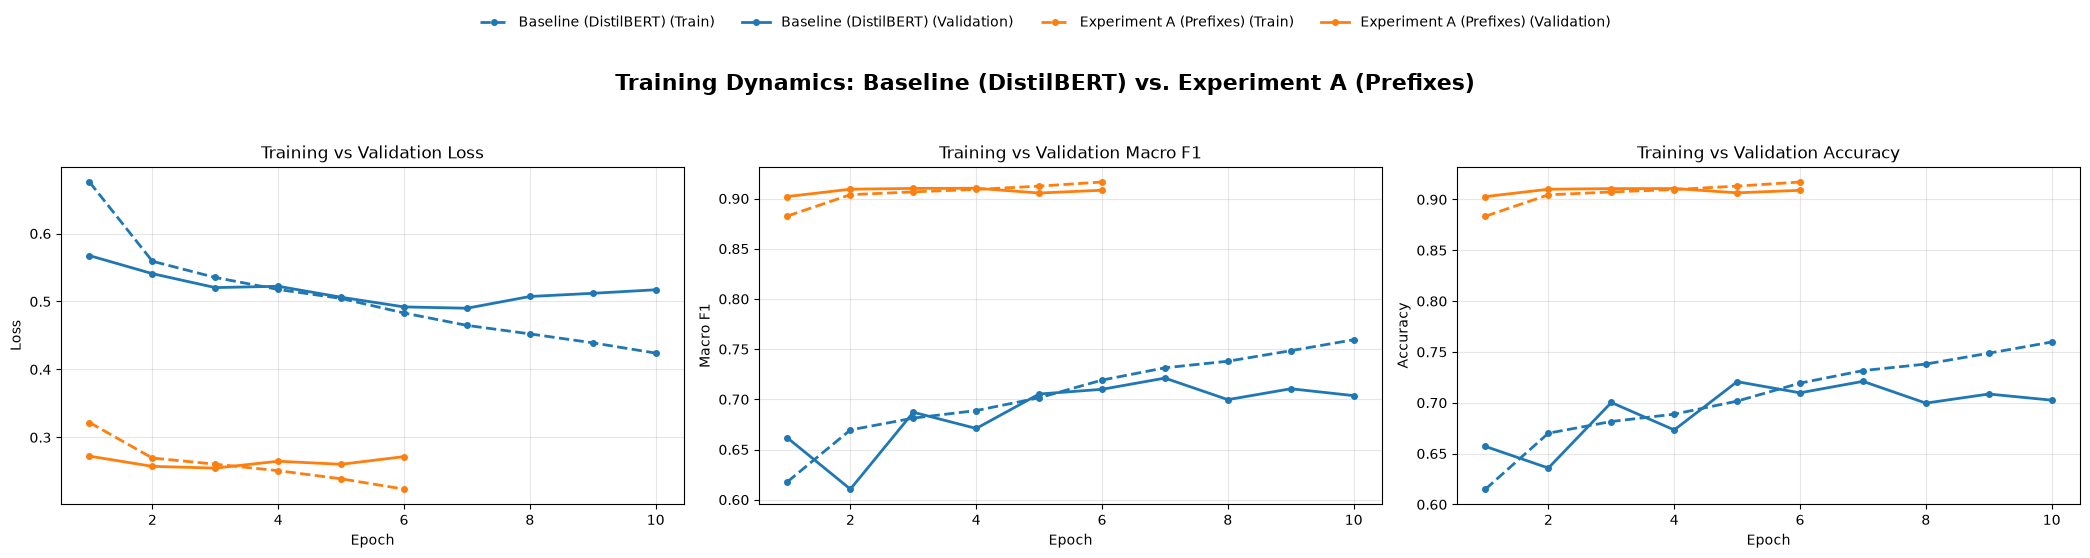

In [ ]:
# Training Curves
fig, axes = plot_model_comparison(
    model1_history=baseline_distilbert,
    model1_name="Baseline (DistilBERT)",
    model2_history=exp_a_results,
    model2_name="Experiment A (Prefixes)",
    save_dir=FIGURE_PATH,
    filename="experiment_a_comparison_curves.png",
)

## 7. Experimental Results

The trained Experiment A model was evaluated on the held-out test set and compared directly with the baseline model. Performance is assessed using the confusion matrix and standard classification metrics to determine whether explicit event-side annotations improve directional momentum classification.

### 7.1 Classification Report

In [12]:
from IPython.display import Markdown, display

with open(REPORTS_PATH / 'bert_momentum.txt', 'r') as f:
    report_experiment_a = f.read()

display(Markdown('### Experiment A - Home/Away Prefix'))
print(report_experiment_a)

### Experiment A - Home/Away Prefix

 DistilBERT - Test Set Evaluation
               precision    recall  f1-score   support

Home Dominant       0.94      0.92      0.93      9492
Away Dominant       0.93      0.91      0.92      7095
     Balanced       0.85      0.90      0.87      7870

     accuracy                           0.91     24457
    macro avg       0.91      0.91      0.91     24457
 weighted avg       0.91      0.91      0.91     24457



### 7.3 Comparison with Baseline

In [11]:
from helper import load_report, compare_classification_reports

report_baseline = load_report(BASE_DIR / 'reports' /'metrics' / 'baseline' /"bert_momentum_metrics.txt")
report_a = load_report(REPORTS_PATH / "bert_momentum_metrics.txt")

summary = compare_classification_reports(
    report_baseline,
    report_a,
    names=("Baseline", "Experiment A - Prefix")
)

display(
    summary.style
    .format({
        "Baseline": "{:.4f}",
        "Experiment A - Prefix": "{:.4f}",
        "Δ": "{:+.4f}",
    })
    .background_gradient(subset=["Δ"], cmap="RdYlGn")
    .hide(axis="index")
)

Metric,Baseline,Experiment A - Prefix,Δ
Accuracy,0.7202,0.9086,+0.1885
Macro Precision,0.7225,0.9081,+0.1857
Macro Recall,0.7258,0.9078,+0.1820
Macro F1,0.7218,0.9077,+0.1860
Weighted F1,0.7208,0.9090,+0.1883
Home Dominant F1,0.6464,0.9316,+0.2853
Away Dominant F1,0.5960,0.9174,+0.3214
Balanced F1,0.9230,0.8742,-0.0488


### 7.2 Confusion Matrix

In [2]:
# Load preds & labels

# baseline
baseline_preds = np.load(BASE_DIR / 'reports' / 'metrics' / 'baseline' / 'bert_momentum_preds.npy')
baseline_labels = np.load(BASE_DIR / 'reports' / 'metrics' / 'baseline' / 'bert_momentum_labels.npy')

#experiment a 
exp_a_preds = np.load(REPORTS_PATH/'bert_momentum_preds.npy')
exp_a_labels = np.load(REPORTS_PATH/'bert_momentum_labels.npy')

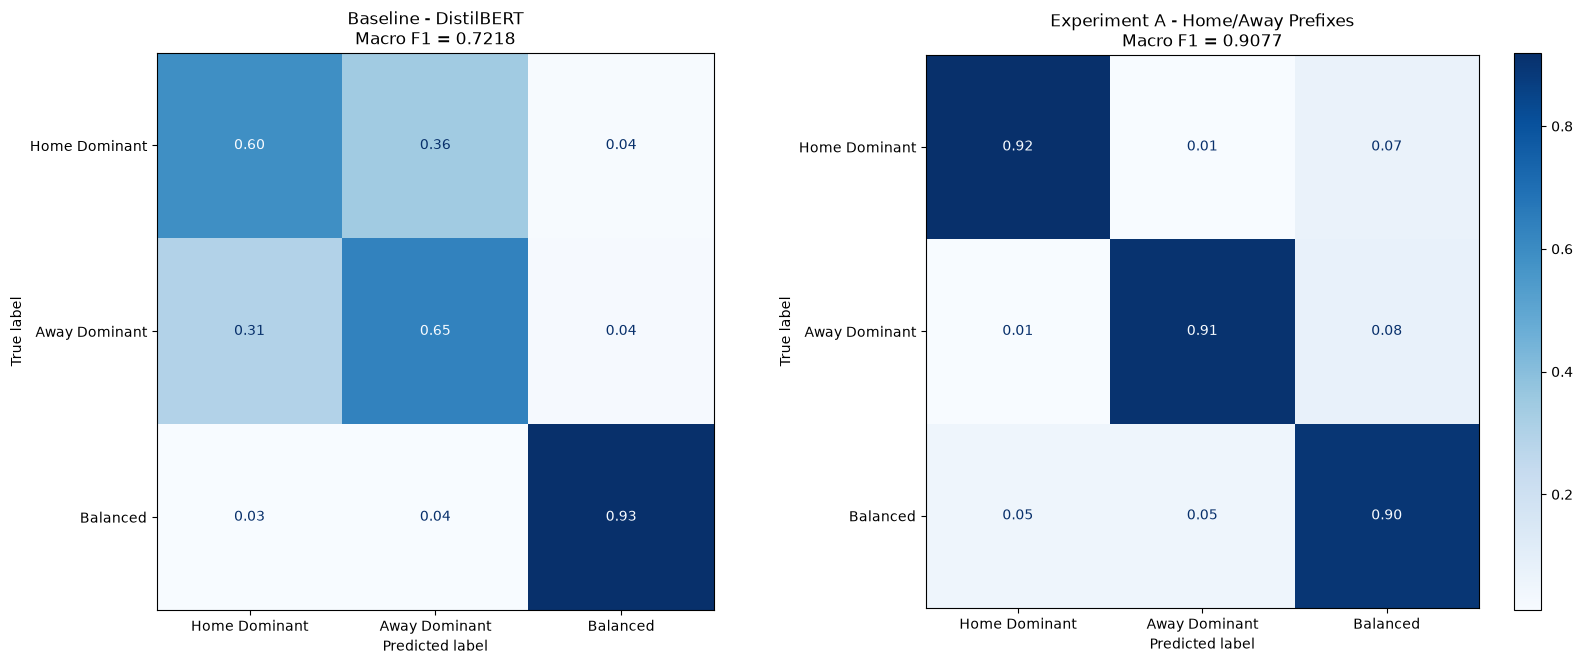

In [8]:
# Confusion Matrix
plot_confusion_matrices(
    model1_true=baseline_labels,
    model1_preds=baseline_preds,
    model2_true=exp_a_labels,
    model2_preds=exp_a_preds,
    display_labels=CLASS_NAMES,
    model1_name="Baseline - DistilBERT",
    model2_name="Experiment A - Home/Away Prefixes",
    save_dir=FIGURE_PATH,
    filename="experiment_b_comparison_cm.png",
)

Compared with the baseline model, explicit event-side annotations reduced Home↔Away directional confusion from 5,623 errors to 208, after introducing explicit event-side annotations, representing a 96.3% reduction, confirming that the baseline model's primary limitation was identifying which team generated momentum rather than recognizing momentum-related events.

In [ ]:
baseline_direction_errors = 3415 + 2208
exp_direction_errors = 109 + 99

reduction = (
    baseline_direction_errors
    - exp_direction_errors
) / baseline_direction_errors

print(reduction)

0.963009069891517


### Key Observation

Explicit event-side annotations reduced Home Dominant ↔ Away Dominant misclassifications by 96.3%, indicating that the baseline model's primary limitation was associating football events with the correct team rather than recognizing momentum-related events. The remaining errors are predominantly between the Balanced class and the directional momentum classes, suggesting that future work should focus on improving the distinction between sustained momentum and genuinely balanced periods.

## 8. Discussion

The baseline DistilBERT model demonstrated strong performance on the Balanced class but frequently confused the Home Dominant and Away Dominant classes. Error analysis suggested that the model could recognize momentum-related football events but often lacked sufficient information to determine which team generated those events.

To test this hypothesis, each commentary event was explicitly annotated with its originating side using `[HOME_TEAM]` and `[AWAY_TEAM]` prefixes while keeping the model architecture, training procedure, and data split unchanged.

The results strongly support the hypothesis. Macro F1 improved from **0.72** to **0.91**, while directional confusion between the Home Dominant and Away Dominant classes decreased by **96.3%**. This indicates that the baseline model's primary limitation was associating events with the correct team rather than understanding football commentary itself.

Performance on the Balanced class decreased slightly, suggesting that once explicit team information became available, the model became more confident in assigning directional momentum instead of predicting the neutral class.

## 9. Conclusion

This experiment demonstrates that relatively simple domain-specific feature engineering can substantially improve transformer-based text classification without modifying the model architecture.

By explicitly identifying the team responsible for each event, the model learned to attribute momentum more accurately, resulting in significantly improved classification of Home Dominant and Away Dominant periods.

The remaining errors are primarily between the Balanced class and the directional momentum classes, indicating that future improvements should focus on distinguishing genuinely balanced periods from sustained attacking pressure rather than identifying which team is attacking.

Overall, this experiment validates the importance of incorporating domain knowledge into natural language processing pipelines for sports analytics.

## 10. Remaining Error Analysis

Let's look at some misclassified examples in this section, the model has improved in identifying home dominant & away dominant because of annotations in Experiment A,
but it still was misclassifying Balanced momentum as Home / Away or vice versa. We will be looking at some examples that were misclassified.


In [ ]:
distribution = pd.DataFrame({
    'True': test_df["label"].value_counts(normalize=True).sort_index(),
    "Predicted": pd.Series(exp_a_preds).value_counts(normalize=True).sort_index()
})
display(distribution)

,True,Predicted
0,0.388110,0.378297
1,0.290101,0.284581
2,0.321789,0.337122


In [ ]:
# Making an error dataframe
error_df = test_df.copy()

error_df['True Label'] = exp_a_labels
error_df['Predicted Label'] = exp_a_preds

error_df['Correct'] = (
    error_df['True Label'] == 
    error_df['Predicted Label']
)

# Errors -> everything not correct
errors = error_df[~error_df["Correct"]].copy()

# Change to label names
label_map = {
    0: "Home Dominant",
    1: "Away Dominant",
    2: "Balanced"
}

# Apply mapping
errors["True"] = errors["True Label"].map(label_map)
errors["Predicted"] = errors["Predicted Label"].map(label_map)

In [ ]:
# Display most error types by the model
errors["Error Type"] = (
    errors["True"] +
    " → " +
    errors["Predicted"]
)
errors["Error Type"].value_counts()

Error Type
Home Dominant → Balanced         652
Away Dominant → Balanced         549
Balanced → Home Dominant         422
Balanced → Away Dominant         404
Home Dominant → Away Dominant    109
Away Dominant → Home Dominant     99
Name: count, dtype: int64

In [ ]:
home_to_balanced = errors[
    (errors["True"] == "Home Dominant") &
    (errors["Predicted"] == "Balanced")
].sample(4, random_state=42)

away_to_balanced = errors[
    (errors["True"] == "Away Dominant") &
    (errors["Predicted"] == "Balanced")
].sample(4, random_state=42)

balanced_to_home = errors[
    (errors["True"] == "Balanced") &
    (errors["Predicted"] == "Home Dominant")
].sample(4, random_state=42)

balanced_to_away = errors[
    (errors["True"] == "Balanced") &
    (errors["Predicted"] == "Away Dominant")
].sample(4, random_state=42)

In [ ]:
def print_examples(df, title):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")

    for i, (_, row) in enumerate(df.iterrows(), start=1):
        print(f"Example {i}")
        print(f"Text      : {row['text']}")
        print(f"True      : {row['True']}")
        print(f"Predicted : {row['Predicted']}")
        print("-" * 100)


print_examples(home_to_balanced, "Home Dominant → Balanced")
print_examples(balanced_to_home, "Balanced → Home Dominant")
print_examples(away_to_balanced, "Away Dominant → Balanced")
print_examples(balanced_to_away, "Balanced → Away Dominant")


Home Dominant → Balanced
Example 1
Text      : [HOME_TEAM] Attempt saved. Salomon Kalou (Hertha Berlin) right footed shot from outside the box is saved in the top left corner. Assisted by Vladimir Darida. [HOME_TEAM] Corner,  Hertha Berlin. Conceded by Jaroslav Drobny. [HOME_TEAM] Foul by Valentin Stocker (Hertha Berlin). [AWAY_TEAM] Robert Bauer (SV Werder Bremen) wins a free kick in the defensive half. [AWAY_TEAM] Attempt missed. Serge Gnabry (SV Werder Bremen) right footed shot from outside the box is close, but misses to the left. Assisted by Claudio Pizarro. [HOME_TEAM] Attempt saved. Vedad Ibisevic (Hertha Berlin) right footed shot from the left side of the box is saved in the top centre of the goal. Assisted by Salomon Kalou.
True      : Home Dominant
Predicted : Balanced
----------------------------------------------------------------------------------------------------
Example 2
Text      : [HOME_TEAM] Phil Jagielka (Everton) wins a free kick on the right wing. [AWAY_TEAM] Fo

### 10.1 Boundary Sensitivity Analysis

The qualitative examples above suggest that many misclassifications occur in windows with genuinely mixed or marginal momentum: events from both sides, or no single dominant pattern. To test this quantitatively, we examined whether prediction errors are concentrated near the momentum-score label boundaries (±2, the thresholds used to assign Home Dominant, Away Dominant, and Balanced labels).

In [3]:
preds = exp_a_preds
labels = exp_a_labels
test_df = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'test.csv')

assert len(preds) == len(test_df), "Row count mismatch — check ordering assumption"

In [4]:
test_df['pred'] = preds
test_df['correct'] = (test_df['label'].values == preds)

# Bucket by distance from nearest label boundary (±2)
test_df['dist_from_boundary'] = (test_df['momentum_score'].abs() - 2).abs()

# Compare error rate for "near boundary" vs "far from boundary"
near = test_df[test_df['dist_from_boundary'] <= 0.5]
far = test_df[test_df['dist_from_boundary'] > 0.5]

# Error rates
near_error_rate = 1 - near['correct'].mean()
far_error_rate = 1 - far['correct'].mean()

print("Error rate near boundary:", near_error_rate)
print("Error rate far from boundary:", far_error_rate)

Error rate near boundary: 0.18747750989564593
Error rate far from boundary: 0.07906633453270595


In [5]:
# Fraction of total errors that are near the boundary
near_errors = (~near['correct']).sum()
total_errors = (~test_df['correct']).sum()

boundary_window = len(near) / len(test_df)

print("Near errors:", near_errors)
print("Total errors:", total_errors)
print("Boundary window:", boundary_window)
print("Near errors / total errors:", near_errors / total_errors)

Near errors: 521
Total errors: 2235
Boundary window: 0.11362800016355236
Near errors / total errors: 0.23310961968680088


For each test window, we computed its distance from the nearest boundary and grouped windows into distance buckets:

In [6]:
bins = [0, 0.25, 0.5, 1.0, 2.0, np.inf]
test_df['boundary_bucket'] = pd.cut(test_df['dist_from_boundary'], bins=bins)

summary = test_df.groupby('boundary_bucket', observed=True).agg(
    n=('correct', 'size'),
    error_rate=('correct', lambda x: 1 - x.mean())
)
print(summary)

                    n  error_rate
boundary_bucket                  
(0.25, 0.5]      1194    0.188442
(0.5, 1.0]       6363    0.103725
(1.0, 2.0]       7817    0.081233
(2.0, inf]       7498    0.055882


Error rate declines monotonically with distance from the boundary — windows within 0.5 of a threshold are misclassified at roughly 3.4x the rate of windows far from any boundary (0.188 vs 0.056). These near-boundary windows make up only 11.4% of the test set but account for 23.3% of all errors.
We further examined which classes were involved in these near-boundary errors:

In [7]:
label_map = {
    0: "Home Dominant",
    1: "Away Dominant",
    2: "Balanced"
}
near_df = test_df[test_df['dist_from_boundary'] <= 0.5]

pd.crosstab(
    near_df['label'].map(label_map),
    near_df['pred'].map(label_map),
    rownames=['True'],
    colnames=['Predicted']
)

Predicted,Away Dominant,Balanced,Home Dominant
True,,,
Away Dominant,866,148,43
Balanced,66,374,55
Home Dominant,42,167,1018


Of the 521 near-boundary errors, 436 (83.7%) involve the Balanced class as either the true or predicted label, compared to only 85 (16.3%) that are direct Home↔Away confusions. This directly explains a pattern visible in the error-type table above: Home/Away↔Balanced confusions (2,027 total) vastly outnumber pure Home↔Away confusions (208 total).

### Interpretation: 

These results suggest that a substantial share of the model's residual errors: particularly those involving the Balanced class often stem from windows where the momentum score sits close to an essentially arbitrary threshold, rather than from the model failing to understand the underlying text. A window with a momentum score of 2.1 and one of 1.9 are treated as different classes despite representing near-identical match states. This is a limitation of the label construction, not solely a limitation of the model, and it suggests that Balanced-class performance has a structural ceiling that further model tuning is unlikely to fully close. Future work could explore soft or ordinal label formulations (e.g., treating momentum as a continuous score rather than a hard three-way threshold) to better reflect this ambiguity.